# word2vec
추론 기반 기법을 이용해서 단어의 분산 표현을 얻어보자. 이 기법은 신경망을 이용하는데 그 중에 가장 유명한 word2vec 모델이 나온다. 이를 구현하고 이해 해보자.

## 추론 기반 기법과 신경망

### 통계 기반 기법의 문제점
현업에서 사용하는 말뭉치의 어휘 수는 100만을 훌쩍 넘는다고 한다. 만약 그 어휘로 통계 기반 기법을 사용하면 100만x100만 행렬을 만들게 되고 이를 또 SVD를 적용하는 것은 현실적이지 않다.  
통계 기반 기법은 말뭉치 전체를 1번에 처리하지만 추론 기반 기법은 신경망을 이용하기 때문에 미니배치로 학습하는 것이 일반적이다. 신경망이 소량(미니배치)의 학습 샘플로 반복하여 가중치를 갱신한다. 

### 추론 기반 기법의 개요
맥락 즉 주변 단어가 주어지면 그 사이에 어떤 단어가 들어갈지를 추측하는 작업을 하는 것이다. 그래서 그 추측 작업을 신경망을 사용한 모델을 사용하여 어떤 맥락 정보를 입력 받아서 각 단어의 출현 확률을 출력한다.  
신경망에서는 단어를 처리하려면 고정 길이 벡터로 변환해야 한다. 이때 사용하는 방법이 원핫 벡터로 변환한다. 이는 벡터의 원소 중 하나만 1이고 나머지는 모두 0인 벡터이다. 이로써 단어를 벡터로 표현하여 계층에서 처리할 수 있게 되었다. 그래서 완전연결계층에 의한 변환을 코드로 작성해보면

In [1]:
import numpy as np
import sys

c = np.array([1, 0, 0, 0, 0, 0, 0]) # 원핫 벡터의 모양이다.
W = np.random.randn(7, 3)
h = np.matmul(c, W) # 편향을 생략하기 때문에 행렬 곱으로 수행하면 된다.
print(h)

# or
sys.path.append('..')
from layers import MatMul

c = np.array([1, 0, 0, 0, 0, 0, 0])
W = np.random.randn(7, 3)
layer = MatMul(W)
h = layer.forward(c)
print(h)

[-1.32824211 -0.97413134  1.21186445]
[2.14176137 0.67291546 1.09108077]


## 단순한 word2vec
이번 절에서 사용한 신경망은 word2vec이 제안하는 CBOW(countinuous bag-of-words) 모델이다.

이 모델은 원핫 벡터로 표현된 맥락(주변 단어) n개로부터 타깃(중앙 단어)을 추측하는 용도의 신경망이다. n은 맥락으로 고려할 단어의 개수를 의미한다. 여기서 은닉층의 뉴런은 완전연결계층에 의해서 변환된 값이 되는데 입력이 여러 개이므로 전체를 평균해야 한다. 그리고 출력의 뉴련은 각각의 단어의 점수를 뜻하고 점수가 높을 수록 대응 단어의 출현 빈도가 올라간다. 이 점수에 소프트맥스 함수를 적용하여 확률을 얻을 수 있다. 입력층에서 은닉층으로의 변환은 가중치에 의해서 이루어지는데 이 가중치가 단어의 분산 표현이다. 그리고 이 가중치는 입력층의 뉴런 수보다 작게 해야 한다. 그래야 단어의 의미를 간결하게 담고 밀집벡터의 표현을 얻을 수 있다. 그러나 이는 인간이 보기 어려운데 디코딩을 통해서 이해 가능하게 바꿀 수 있다.  
CBOW를 코드로 구현 해보자. 코드를 잘 보면 활성화 함수를 사용하지 않는 간단한 구성이다.

In [2]:
import sys
sys.path.append('..')
import numpy as np
from layers import MatMul


# 샘플 맥락 데이터
c0 = np.array([[1, 0, 0, 0, 0, 0, 0]])
c1 = np.array([[0, 0, 1, 0, 0, 0, 0]])

# 가중치 초기화
W_in = np.random.randn(7, 3)
W_out = np.random.randn(3, 7)

# 계층 생성
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

# 순전파
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)
print(s)

[[-1.95785294 -0.7942286  -0.08753264 -0.15532256 -1.95838688  1.39410226
   0.0035142 ]]


### CBOW 모델의 학습
모델의 결과인 점수를 소프트 맥스 함수를 적용하면 확률을 얻을 수 있는데 이는 맥락이 주어졌었을 때 그 중앙에 어떤 단어가 출현하는지를 나타낸다.
그래서 이 모델을 학습시키는 것은 올바른 예측을 위한 가중치 조정을 하는 것이다. 그 학습의 결과로 단어의 출현 패턴을 파악한 벡터가 학습되는 것이다. 그리고 그 결과는 우리의 직관과 부합하는 경우가 많다.  
모델 학습을 위해서 아까 구현한 CBOW에 소프트맥스 함수와 교차 엔트로피 오류 계층을 사용하면 된다.   
  
가중치에 대해서 조금 더 살펴본다면 두 가지가 있는데 입력, 출력 측 완전연결계층의 가중치가 있다. 입력 측 가중치는 각 행이 각 단어의 분산 표현에 해당한다. 출력 측 가중치는 단어의 의미가 인코딩된 벡터가 저장되고 있다. 하지만 입력과 다르게 열 방향으로 저장된다. 그래서 우리는 최종적인 단어의 분산 표현으로 3가지의 가중치를 선택할 수 있다.
* 입력 측 가중치만 사용
* 출력 측 가중치만 사용
* 입력, 출력 측 가중치 모두 사용
그래서 word2vec은 입력 측의 가중치만 이용한다를 선택하였다. 

## 학습 데이터 준비
word2vec에서 이용하는 신경망의 입력은 맥락이고 정답 레이블은 맥락에 싸인 중앙 단어인 타깃이다. 그래서 다음과 같이 코드를 작성할 수 있다.

In [3]:
import numpy as np
import sys
sys.path.append("..")
from util import preprocess

def create_contexts_target(corpus, window_size=1):
    '''맥락과 타깃 생성

    :param corpus: 말뭉치(단어 ID 목록)
    :param window_size: 윈도우 크기(윈도우 크기가 1이면 타깃 단어 좌우 한 단어씩이 맥락에 포함)
    :return:
    '''
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus)-window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)

text = "you say goodby and i say hello."
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus)
print(id_to_word)

contexts, target = create_contexts_target(corpus, window_size=1)
print(contexts)
print(target)

# 원핫 벡터로 바꾸기
def convert_one_hot(corpus, vocab_size):
    '''원핫 표현으로 변환

    :param corpus: 단어 ID 목록(1차원 또는 2차원 넘파이 배열)
    :param vocab_size: 어휘 수
    :return: 원핫 표현(2차원 또는 3차원 넘파이 배열)
    '''
    N = corpus.shape[0]

    if corpus.ndim == 1:
        one_hot = np.zeros((N, vocab_size), dtype=np.int32)
        for idx, word_id in enumerate(corpus):
            one_hot[idx, word_id] = 1

    elif corpus.ndim == 2:
        C = corpus.shape[1]
        one_hot = np.zeros((N, C, vocab_size), dtype=np.int32)
        for idx_0, word_ids in enumerate(corpus):
            for idx_1, word_id in enumerate(word_ids):
                one_hot[idx_0, idx_1, word_id] = 1

    return one_hot

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)
print(contexts)
print(target)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodby', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}
[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
[1 2 3 4 1 5]
[[[1 0 0 0 0 0 0]
  [0 0 1 0 0 0 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 1 0 0 0]]

 [[0 0 1 0 0 0 0]
  [0 0 0 0 1 0 0]]

 [[0 0 0 1 0 0 0]
  [0 1 0 0 0 0 0]]

 [[0 0 0 0 1 0 0]
  [0 0 0 0 0 1 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 0 0 0 1]]]
[[0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0]]


## CBOW 모델 구현

In [4]:
import sys
sys.path.append('..')
import numpy as np
from layers import MatMul, SoftmaxWithLoss


class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 계층 생성
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모은다.
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장한다.
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None

| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 26 |

c:\Users\vilab\csw\deep_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vilab\csw\deep_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vilab\csw\deep_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vilab\csw\deep_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


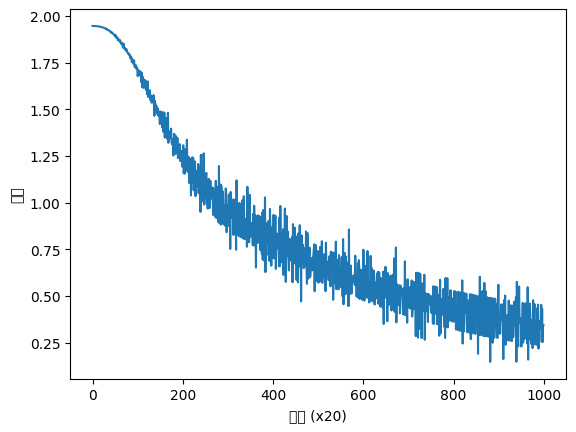

you [-1.6625056 -0.9256252  0.8507776 -0.8755836 -0.9536213]
say [-0.41034138  1.1622205  -1.1809411   1.1620885   1.1912295 ]
goodbye [ 0.39567804 -1.0852656   1.1128986  -1.1046747  -1.0423537 ]
and [-1.8005239   0.76157236 -0.72080374  0.709278    0.8549368 ]
i [ 0.39461336 -1.0682408   1.0808114  -1.0695548  -1.0640064 ]
hello [-1.6574515 -0.9200223  0.8566939 -0.8881494 -0.931952 ]
. [ 1.6213377  1.1898795 -1.2695307  1.2229409  1.2054752]


In [5]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
from trainer import Trainer
from optimizer import Adam
from util import preprocess, create_contexts_target, convert_one_hot


window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

### CBOW 모델과 확률
A가 일어날 확률은 P(A)라 쓰고 A, B가 동시에 일어날 확률인 동시 확률은 P(A, B)이고 B가 일어났을 때 A가 일어날 확률을 사후확률이라고 하는데 P(A|B)라고 쓴다. 이를 바탕으로 CBOW모델을 수식화 해본다면 $P(w_t \mid w_{t-1}, w_{t+1})$ 을 모델링 하고 있는 것이다. 그리고 이를 이용한 손실 함수도 유도 할 수 있다. $L = -\log P(w_t \mid  w_{t-1}, w_{t+1})$ 이는 샘플 하나에 대한 손실 함수이고 이를 말뭉치 전체로 확장하면, $L = -\frac{1}{T} \sum_{t=1}^{T} \log P(w_t \mid w_{t-1}, w_{t+1})$

### skip-gram 모델
word2vec은 두 개의 모델을 제안하고 있는데 그 중 하나가 CBOW이고 나머지가 skip-gram이다. skip-gram은 CBOW를 입력과 출력을 역전시킨 모델이다. 그래서 입력 층은 하나이지만 출력층은 맥락의 수만큼 존재해서 출력층 각각에 손실을 구하고 개별 손실을 모두 더한 값을 최종 손실로 한다. 그래서 수식으로 모델링 한다면 $P(w_{t-1}, w_{t+1} \mid w_t)$ 이라 할 수 있다. 그리고 skip-gram 모델에서는 맥락의 단어들 사이의 관련성이 없다고 가정해서 즉 조건부 독립이여서 $P(w_{t-1}, w_{t+1} \mid w_t) = P(w_{t-1} \mid w_t)P(w_{t+1} \mid w_t)$ 로 바꿀 수 있고 이 식을 교차 엔트로피 오차에 적용하면 $L = -\log P(w_{t-1} \mid w_t)P(w_{t+1} \mid w_t) = -(\log P(w_{t-1} \mid w_t) + \log P(w_{t+1} \mid w_t))$ 이라고 할 수 있고 이를 또 말뭉치 전체로 확장하면 $L = -\frac{1}{T} \sum_{t=1}^{T} (\log P(w_{t-1} \mid w_t) + \log P(w_{t+1} \mid w_t))$ 이다.  
  
두 개의 모델을 살펴보았는데 단어 분산 표현의 정밀도 그리고 말뭉치가 커지고 저빈도 단어나 유추 문제 성능에서는 skip-gram모델이 뛰어난 경향을 보인다. 하지만 학습 속도에서는 손실을 맥락의 수만큼 구해야 해서 계산 비용이 커져서 느리다.

### 통계 vs 추론 기반
앞에서도 비교 했지만 더 알아보면 어휘가 추가로 생겨서 단어의 분산 표현을 갱신해야 할 때 통계는 새로 다 계산 해야 하지만 추론 기반은 그렇지 않다. 그리고 단어 분산 표현의 성격이나 정밀도에서 통계는 유사성만 인코딩 되지만 우리가 살펴본 추론 기반에서는 유사성과 단어 사이의 패턴도 알아 낼 수 있다. 하지만 실제 정량 평가 결과는 서로 우열을 가릴 수 없었다. 추가로 서로의 기법은 관련되어 있다. GloVe기법을 참고하자. 